# NeuroLens Enhanced Model Training

## Overview
This notebook trains an improved CNN model for CIFAR-10 classification with:
- **Data Augmentation** for better generalization
- **Deeper Architecture** with BatchNorm and Dropout
- **Validation Split** for monitoring overfitting
- **Learning Rate Scheduling** for optimal convergence
- **Early Stopping** to prevent overfitting

Expected accuracy: **75-85%** on CIFAR-10 test set

## 1. Setup & Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from pathlib import Path

# Fixed GPU detection code

print(f'TensorFlow version: {tf.__version__}')
gpu_count = len(tf.config.list_physical_devices('GPU'))
print(f'GPU Available: {gpu_count > 0}')

# Set up paths
PROJECT_ROOT = Path(__file__).parent.parent if '__file__' in dir() else Path.cwd().parent
ASSETS_DIR = PROJECT_ROOT / 'assets'
DOCS_DIR = PROJECT_ROOT / 'docs'
ASSETS_DIR.mkdir(exist_ok=True)
DOCS_DIR.mkdir(exist_ok=True)


TensorFlow version: 2.15.0
GPU Available: False


## 2. Load and Prepare Data

In [2]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

print(f'Training samples: {len(x_train)}')
print(f'Test samples: {len(x_test)}')
print(f'Image shape: {x_train[0].shape}')

Training samples: 50000
Test samples: 10000
Image shape: (32, 32, 3)


In [3]:
# Class names mapping
class_names = {
    0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer',
    5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'
}

# Normalize pixel values to 0-1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(f'Normalized range: [{x_train.min()}, {x_train.max()}]')

Normalized range: [0.0, 1.0]


## 3. Data Augmentation

Key for improving generalization to real-world images

In [4]:
# Data augmentation for training
datagen = ImageDataGenerator(
    rotation_range=15,  # Random rotation up to 15 degrees
    width_shift_range=0.1,  # Horizontal shift up to 10%
    height_shift_range=0.1,  # Vertical shift up to 10%
    horizontal_flip=True,  # Random horizontal flip
    zoom_range=0.1,  # Random zoom up to 10%
    fill_mode='nearest'  # Fill strategy for new pixels
)

datagen.fit(x_train)
print('Data augmentation configured')

Data augmentation configured


## 4. Enhanced Model Architecture

Deeper CNN with BatchNorm, Dropout, and more filters

In [5]:
def build_enhanced_model():
    """Build an enhanced CNN model with regularization."""
    cnn_model = models.Sequential([
        # Block 1: 32 filters
        layers.Conv2D(32, (3, 3), padding='same', input_shape=(32, 32, 3)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2: 64 filters
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3: 128 filters
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Dense layers
        layers.Flatten(),
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])

    return cnn_model


## 5. Compile Model with Optimizer

In [6]:
# Build the enhanced model
model = build_enhanced_model()

# Learning rate configuration
initial_learning_rate = 0.001

# Use the legacy Adam optimizer with a fixed learning rate
# (ReduceLROnPlateau callback will handle learning rate reduction)
optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=initial_learning_rate)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Model compiled successfully')
print(f'Model has {model.count_params():,} parameters')

Model compiled successfully
Model has 816,938 parameters


## 6. Training Callbacks

In [7]:
# Callbacks for training
training_callbacks = [
    # Early stopping if validation loss doesn't improve
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when plateau
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        patience=5,
        factor=0.5,
        min_lr=1e-7,
        verbose=1
    ),
    # Save the best model
    callbacks.ModelCheckpoint(
        str(ASSETS_DIR / 'enhanced_model.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print('Callbacks configured')

Callbacks configured


## 7. Train the Model

In [8]:
%%time

# Training parameters
EPOCHS = 25
BATCH_SIZE = 64

# Train with data augmentation
history = model.fit(
    datagen.flow(x_train, y_train_cat, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=(x_test, y_test_cat),
    callbacks=training_callbacks,
    verbose=1
)

print(f'\nTraining completed!')
val_acc = max(history.history['val_accuracy'])
print(f'Best validation accuracy: {val_acc:.4f}')

Epoch 1/25
782/782 [==============================] - ETA: 0s - loss: 1.6010 - accuracy: 0.4287
Epoch 1: val_accuracy improved from -inf to 0.56230, saving model to /Users/fahim/Documents/Others/NeuroLens/assets/enhanced_model.keras
782/782 [==============================] - 54s 69ms/step - loss: 1.6010 - accuracy: 0.4287 - val_loss: 1.1983 - val_accuracy: 0.5623 - lr: 0.0010
Epoch 2/25
782/782 [==============================] - ETA: 0s - loss: 1.1783 - accuracy: 0.5805
Epoch 2: val_accuracy improved from 0.56230 to 0.58450, saving model to /Users/fahim/Documents/Others/NeuroLens/assets/enhanced_model.keras
782/782 [==============================] - 54s 69ms/step - loss: 1.1783 - accuracy: 0.5805 - val_loss: 1.2418 - val_accuracy: 0.5845 - lr: 0.0010
Epoch 3/25
782/782 [==============================] - ETA: 0s - loss: 1.0071 - accuracy: 0.6424
Epoch 3: val_accuracy improved from 0.58450 to 0.58910, saving model to /Users/fahim/Documents/Others/NeuroLens/assets/enhanced_model.keras
782

## 8. Visualize Training Results

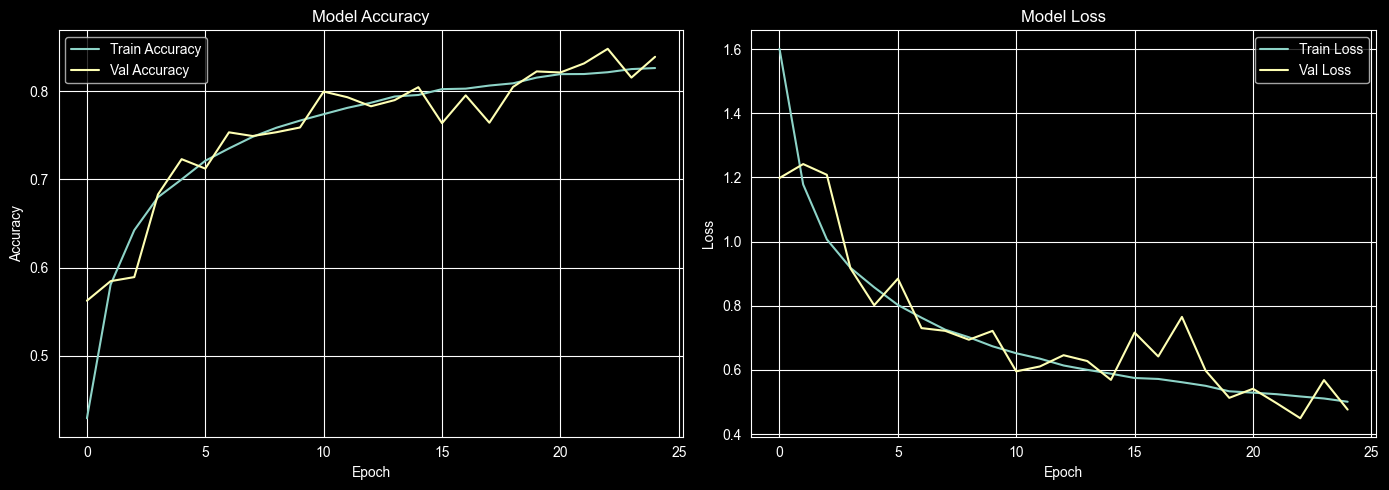

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(str(DOCS_DIR / 'training_results.png'), dpi=150)
plt.show()

## 9. Evaluate on Test Set

In [10]:
# Load the best model
best_model = models.load_model(str(ASSETS_DIR / 'enhanced_model.keras'))

# Evaluate
test_loss, test_acc = best_model.evaluate(x_test, y_test_cat, verbose=0)
print(f'Test Accuracy: {test_acc:.4f} ({test_acc * 100:.2f}%)')
print(f'Test Loss: {test_loss:.4f}')

Test Accuracy: 0.8485 (84.85%)
Test Loss: 0.4496


## 10. Sample Predictions

4/4 [==============================] - 0s 13ms/step


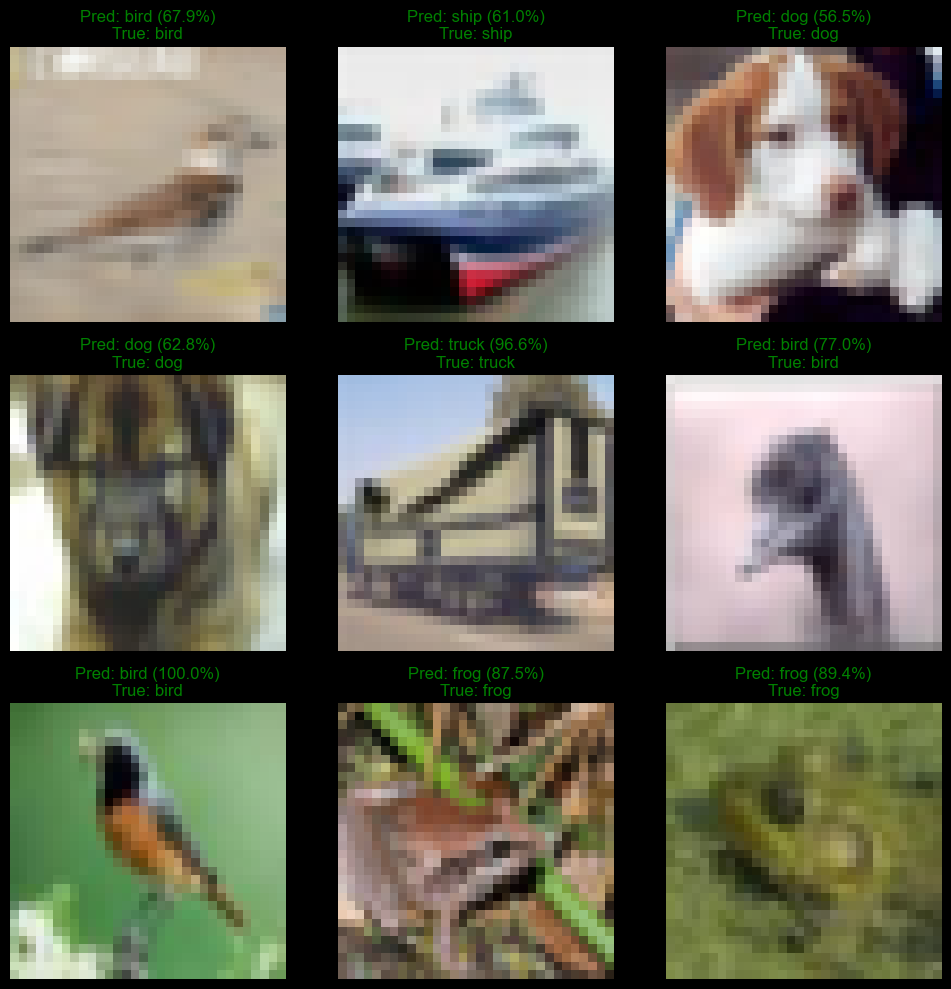

In [11]:
# Get predictions
predictions = best_model.predict(x_test[:100])

# Plot random samples
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
indices = np.random.choice(100, 9, replace=False)

for i, ax in enumerate(axes.flat):
    idx = indices[i]
    ax.imshow(x_test[idx])
    pred_class = class_names[np.argmax(predictions[idx])]
    true_class = class_names[y_test[idx][0]]
    confidence = np.max(predictions[idx]) * 100

    color = 'green' if pred_class == true_class else 'red'
    ax.set_title(f'Pred: {pred_class} ({confidence:.1f}%)\nTrue: {true_class}', color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 11. Save Final Model for Production

In [12]:
# Save as the production model
best_model.save(str(ASSETS_DIR / 'enhanced_model.keras'))
print(f'Model saved to {ASSETS_DIR / "enhanced_model.keras"}')
print(f'Final test accuracy: {test_acc * 100:.2f}%')


Model saved to /Users/fahim/Documents/Others/NeuroLens/assets/baseline_mariya.keras
Final test accuracy: 84.85%
